In [1]:
import os
import sys
import copy
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

SCRIPT_DIR = os.path.dirname(os.path.realpath(os.path.join(os.path.dirname(os.getcwd()))))
sys.path.append(SCRIPT_DIR)

import gwfast.gwfastGlobals as glob
import gwfast.waveforms as waveforms
import gwfast.signal as signal
import gwfast.network as network
import gwfast.fisherTools as fTools
import gwfast.gwfastUtils as utils

LSC Algorithm Library (LAL) is not installed, only the GWFAST waveform models are available, namely: TaylorF2, IMRPhenomD, IMRPhenomD_NRTidalv2, IMRPhenomHM and IMRPhenomNSBH
TEOBResumS is not installed, only the GWFAST waveform models are available, namely: TaylorF2, IMRPhenomD, IMRPhenomD_NRTidalv2, IMRPhenomHM and IMRPhenomNSBH


In [2]:
# Set up detectors
mywf = waveforms.IMRPhenomD()

L1_conf = copy.deepcopy(glob.detectors).pop('L1')
L1_conf['psd_path'] = os.path.join(glob.detPath, 'observing_scenarios_paper', 'AplusDesign.txt')

H1_conf = copy.deepcopy(glob.detectors).pop('H1')
H1_conf['psd_path'] = os.path.join(glob.detPath, 'observing_scenarios_paper', 'AplusDesign.txt')

Virgo_conf = copy.deepcopy(glob.detectors).pop('Virgo')
Virgo_conf['psd_path'] =  os.path.join(glob.detPath, 'observing_scenarios_paper', 'avirgo_O5low_NEW.txt')

# Initialise GWSignal objects
L1 = signal.GWSignal(mywf, psd_path=L1_conf['psd_path'], 
                        detector_shape=L1_conf['shape'], det_lat=L1_conf['lat'], 
                        det_long=L1_conf['long'], det_xax=L1_conf['xax'],
                        fmin=10
                        )
H1 = signal.GWSignal(mywf, psd_path=H1_conf['psd_path'], 
                        detector_shape=H1_conf['shape'], det_lat=H1_conf['lat'], 
                        det_long=H1_conf['long'], det_xax=H1_conf['xax'],
                        fmin=10
                        )
Virgo = signal.GWSignal(mywf, psd_path=Virgo_conf['psd_path'], 
                        detector_shape=Virgo_conf['shape'], det_lat=Virgo_conf['lat'], 
                        det_long=Virgo_conf['long'], det_xax=Virgo_conf['xax'],
                        fmin=10
                        )

mySignals = {'L1':L1, 'H1':H1, 'Virgo':Virgo}
myNet = network.DetNet(mySignals)

Using ASD from file /Users/yuranzhang/gwfast_AGN/gwfast_moddd/psds/observing_scenarios_paper/AplusDesign.txt 
Initializing jax...
Jax local device count: 8
Jax  device count: 8
Using ASD from file /Users/yuranzhang/gwfast_AGN/gwfast_moddd/psds/observing_scenarios_paper/AplusDesign.txt 
Initializing jax...
Jax local device count: 8
Jax  device count: 8
Using ASD from file /Users/yuranzhang/gwfast_AGN/gwfast_moddd/psds/observing_scenarios_paper/avirgo_O5low_NEW.txt 
Initializing jax...
Jax local device count: 8
Jax  device count: 8


In [3]:
# Define a benchmark event
n = 100
shape = (n, n)
events = {
    'Mc':np.full(shape, 30), 'eta':np.full(shape, 0.24), 'dL':np.full(shape, 0.8), 'theta':np.full(shape, 1.87), 'phi':np.full(shape, 2.66), 
    'iota':np.full(shape, 0.99*np.pi/2), 'psi':np.full(shape, 4), 'tcoal':np.full(shape, 0), 'Phicoal':np.full(shape, 2), 
    'chiS':np.full(shape, 0.3), 'chiA':np.full(shape, 0.5), 'chi1x':np.full(shape, 0), 'chi2x':np.full(shape, 0), 'chi1y':np.full(shape, 0), 'chi2y':np.full(shape, 0), 
    'LambdaTilde':np.full(shape, 0), 'deltaLambda':np.full(shape, 0), 'ecc':np.full(shape, 0), 
    'R_orbit':np.full(shape, 100), 'M_lz':np.full(shape, 1e4), 'src_pos':np.full(shape, 0.5)
}

# Compute benchmark SNR
event = {key: values[0, 0] for key, values in events.items()}
mySNR = myNet.SNR(event, use_lensing=True, return_all=True)
print("SNR with lensing:", mySNR)

Adding chi1z, chi2z from chiS, chiA
SNR with lensing: {'L1': Array(13.19938096, dtype=float64), 'H1': Array(27.44081629, dtype=float64), 'Virgo': Array(5.86537915, dtype=float64), 'net': 31.010074637246614}


In [4]:
# Sample parameter space
R_orbit_array = np.geomspace(20, 1000, n)
M_lz_array = np.geomspace(5e3, 5e6, n)
src_pos_array = np.linspace(0.05, 0.5, n)
Mc_array = np.linspace(10, 100, n)

In [5]:
# This is the order of parameters in GWStrain
strain_parameters = ['Mc', 'eta', 'dL', 'theta', 'phi', 'iota', 'psi', 
                     'tcoal', 'Phicoal', 'chiS', 'chiA', 'chi1x', 'chi2x', 'chi1y', 'chi2y', 
                     'LambdaTilde', 'deltaLambda', 'ecc']
# Add the lensed parameters as well
strain_parameters += ['R_orbit', 'M_lz', 'src_pos']

# Waveform metadata
sampling_frequency = 1024.  # Hz
duration = 8.  # s

minimum_frequency = 10.  # Hz
# This maximum frequency need not equal to fs/2
maximum_frequency = sampling_frequency / 2 

# This procedure to create coupled time and freq arrays is borrowed from Bilby
N_samples = int(np.round(duration * sampling_frequency))
N_freq_bins = int(np.round(N_samples / 2) + 1)
freq_array = np.linspace(0, sampling_frequency / 2, N_freq_bins)
time_array = np.linspace(0, duration - 1 / sampling_frequency, N_samples)

# Prepare injections
xv, yv = np.meshgrid(R_orbit_array, Mc_array, indexing='xy')
events_copy_1 = events.copy()
events_copy_1['R_orbit'] = xv
events_copy_1['Mc'] = yv

# Generate strains
FD_strain_lensed = np.zeros_like(freq_array, dtype='complex128')
FD_strain_unlensed = np.zeros_like(freq_array, dtype='complex128')

freq_mask = (freq_array > minimum_frequency) * (freq_array < maximum_frequency)
masked_freq_arr = freq_array[freq_mask]

FD_strain_lensed[freq_mask] = \
    L1.GWstrain(masked_freq_arr, *[events_copy_1[key] for key in strain_parameters], 
                use_lensing=True)
FD_strain_unlensed[freq_mask] = \
    L1.GWstrain(masked_freq_arr, *[events_copy_1[key] for key in strain_parameters], 
                use_lensing=False)

ValueError: Incompatible shapes for broadcasting: shapes=[(4015,), (100, 100)]

In [ ]:
# Mismatch definition
def inner_product(frequencies, h1, h2, psd):
    integrand = np.conj(h1) * h2 / psd
    return 4 * np.real(np.trapezoid(integrand, frequencies))

def mismatch(frequencies, h1, h2, psd):
    return inner_product(frequencies, h1-h2, h1-h2, psd) / (2 * (inner_product(frequencies, h1, h1, psd) + inner_product(frequencies, h2, h2, psd)))

In [ ]:

# Interpolate PSD
psd_interp = np.interp(masked_freq_arr, L1.strainFreq, L1.noiseCurve) # change shape!!!

mismatch = mismatch(masked_freq_arr, FD_strain_lensed[freq_mask], FD_strain_unlensed[freq_mask], psd_interp)


In [ ]:
xv, yv = np.meshgrid(R_orbit_array, Mc_array, indexing='xy')
events_copy_1 = events.copy()
events_copy_1['R_orbit'] = xv
events_copy_1['Mc'] = yv

Adding chi1z, chi2z from chiS, chiA


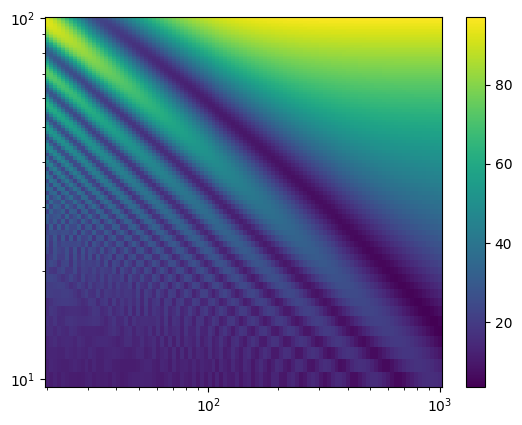

In [ ]:
fig, axs = plt.subplots(1, 1)
im = axs.pcolormesh(R_orbit_array, Mc_array, mismatch)
fig.colorbar(im)
axs.set_xscale('log')
axs.set_yscale('log')